# Experiment 5: Architecture Ablation (M5)

**Purpose:** Address reviewer concern M5 — "no architectural ablation or cross-architecture
validation." Two sub-concerns are tested:

1. **Untested mechanistic claim** — the paper attributes Model D's graceful degradation to the
   slow LIF group's approximate ω-invariance. Arch-B (no slow group) tests this directly.
2. **Single-architecture benchmark** — all paper results use one architecture. Arch-C
   (single-timescale) provides a cross-architecture baseline showing TEMPO is solvable
   by a simpler design.

| Architecture | Hidden groups | Purpose |
|---|---|---|
| **Arch-A** | fast(42) + medium(43) + slow(43) | Full multi-timescale — benchmark baseline (matches Experiments 2 & 3) |
| **Arch-B** | fast(64) + medium(64), **no slow group** | Ablates ω-invariance claim |
| **Arch-C** | fast(128), single-timescale | Cross-architecture baseline; parameter-matched |

All architectures are trained with stochastic TEMPO v1.1 (σ = 0.838 × T_u, ω ~ U[0.8,1.3],
r ~ U[2.5,4.5]) and evaluated on:
- **Experiment 2 conditions**: intact / shuffled / time-collapsed (temporal irreducibility)
- **Experiment 3 noise sweep**: σ_test ∈ {0.0, 0.2, 0.4, 0.6, 0.84, 1.0, 1.2} × T_u (robustness)

In [1]:
import sys, os, math, time, threading, contextlib
import queue as _q
import concurrent.futures

import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import TensorDataset, DataLoader

import snntorch as snn
from snntorch import surrogate

sys.path.insert(0, os.path.join(os.getcwd(), '..'))
from tempo.dataset.generate_dataset import encode_word, MORSE_TABLE

SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)

# Device selection
if torch.cuda.is_available():
    N_CUDA_GPUS = torch.cuda.device_count()
    GPU_DEVICES = [torch.device(f'cuda:{i}') for i in range(N_CUDA_GPUS)]
elif torch.backends.mps.is_available():
    N_CUDA_GPUS = 0
    GPU_DEVICES = [torch.device('mps')]
else:
    N_CUDA_GPUS = 0
    GPU_DEVICES = [torch.device('cpu')]

device = GPU_DEVICES[0]
print(f'Primary device : {device}')
print(f'GPU devices    : {GPU_DEVICES}')

Primary device : cuda:0
GPU devices    : [device(type='cuda', index=0), device(type='cuda', index=1), device(type='cuda', index=2)]


/home/LukeHindman/.local/lib/python3.9/site-packages/torch/cuda/__init__.py:789: UserWarning: Can't initialize NVML
  warnings.warn("Can't initialize NVML")


In [2]:
# ── Transmission parameters ───────────────────────────────────────────────
WPM          = 20
T_U          = int(1200 / WPM)          # 60 ms

# ── TEMPO stochastic protocol (jointly calibrated in Experiment 1) ──────────
SIGMA_FRAC   = 0.575
T_THRESH     = 1.92
# LogNormal parameters (MLE fit, Experiment 52, n=36 recordings)
MU_R,     SIGMA_R     = 1.2269, 0.2916
MU_OMEGA, SIGMA_OMEGA = 0.0360, 0.2446

# ── Spike tensor ──────────────────────────────────────────────────────────
MAX_T        = 1600

# ── Alphabet ──────────────────────────────────────────────────────────────
LETTERS      = [chr(c) for c in range(ord('A'), ord('Z') + 1)]
N_CLASSES    = len(LETTERS)             # 26

# ── Dataset sizes ─────────────────────────────────────────────────────────
N_TRAIN      = 500
N_TEST       = 100

# ── Training ──────────────────────────────────────────────────────────────
N_EPOCHS     = 100
BATCH_SIZE   = 256
N_SEEDS      = 10
LR_INIT      = 5e-4
LR_MIN       = 1e-5

# ── Noise levels for Experiment 3 conditions ──────────────────────────────
SIGMA_TEST_FRACS = [0.00, 0.20, 0.40, 0.575, 0.80, 1.00, 1.20]
SIGMA_TEST_ABS   = [f * T_U for f in SIGMA_TEST_FRACS]

# ── Architecture IDs ──────────────────────────────────────────────────────
ARCH_IDS = ['A', 'B', 'C']

# ── Checkpointing ─────────────────────────────────────────────────────────
CHECKPOINT_DIR = os.path.join('..', 'checkpoints', 'exp5')
os.makedirs(CHECKPOINT_DIR, exist_ok=True)

print(f'T_u        = {T_U} ms')
print(f'Letters    : {" ".join(LETTERS)}')
print(f'Train      : {N_CLASSES} x {N_TRAIN} = {N_CLASSES*N_TRAIN} samples per architecture')
print(f'Test (Exp2): {N_CLASSES} x {N_TEST}  = {N_CLASSES*N_TEST} samples per condition')
print(f'Test (Exp3): {N_CLASSES} x {N_TEST}  = {N_CLASSES*N_TEST} samples per sigma level')
print(f'Epochs     : {N_EPOCHS}  (cosine LR: {LR_INIT} -> {LR_MIN})')
print(f'Seeds      : {N_SEEDS}')
print(f'Total training runs: {len(ARCH_IDS)} archs x {N_SEEDS} seeds = {len(ARCH_IDS)*N_SEEDS}')
print(f'Checkpoint dir : {os.path.abspath(CHECKPOINT_DIR)}')

T_u        = 60 ms
Letters    : A B C D E F G H I J K L M N O P Q R S T U V W X Y Z
Train      : 26 x 500 = 13000 samples per architecture
Test (Exp2): 26 x 100  = 2600 samples per condition
Test (Exp3): 26 x 100  = 2600 samples per sigma level
Epochs     : 100  (cosine LR: 0.0005 -> 1e-05)
Seeds      : 10
Total training runs: 3 archs x 10 seeds = 30
Checkpoint dir : /home/LukeHindman/workspace/tempo/checkpoints/exp5


In [3]:
USE_AMP        = False
USE_CUDA_GRAPH = False

if N_CUDA_GPUS > 0:
    USE_AMP = True
    print(f'CUDA GPUs detected: {N_CUDA_GPUS}')
    for i in range(N_CUDA_GPUS):
        p = torch.cuda.get_device_properties(i)
        bf16 = p.major >= 8
        print(f'  cuda:{i}  {p.name}  {p.total_memory//1024**3} GB  '
              f'cc={p.major}.{p.minor}  BF16={bf16}  SMs={p.multi_processor_count}')
    # CUDA graphs require CUDA; safe with the GPU-pool pattern (one graph per GPU
    # at a time, enforced by _gpool queue). Disabled on pre-Ampere if desired,
    # but graphs work on any CUDA-capable device — only BF16 AMP needs Ampere.
    USE_CUDA_GRAPH = True
else:
    print(f'No CUDA GPUs. Running on: {GPU_DEVICES}')

N_GPU_WORKERS = len(GPU_DEVICES)
print(f'\nN_GPU_WORKERS : {N_GPU_WORKERS}')
print(f'USE_AMP       : {USE_AMP}')
print(f'USE_CUDA_GRAPH: {USE_CUDA_GRAPH}')

CUDA GPUs detected: 3
  cuda:0  NVIDIA L40S  44 GB  cc=8.9  BF16=True  SMs=142
  cuda:1  NVIDIA L40S  44 GB  cc=8.9  BF16=True  SMs=142
  cuda:2  NVIDIA L40S  44 GB  cc=8.9  BF16=True  SMs=142

N_GPU_WORKERS : 3
USE_AMP       : True
USE_CUDA_GRAPH: True


## Architecture Variants

All three architectures share identical `fc1` (2→128) and `fc2` (128→26) weight matrices,
giving approximately equal parameter counts (~3740). The only difference is the number and
configuration of LIF neuron groups in the hidden layer. This ensures accuracy differences
are attributable to timescale structure, not model capacity.

In [4]:
spike_grad = surrogate.fast_sigmoid()


class TempoSNN(nn.Module):
    """Feedforward LIF SNN with configurable hidden-layer neuron groups.

    Parameters
    ----------
    groups : list of (n_neurons, beta_init, threshold)
        Hidden-layer groups. Total hidden size = sum(n for n,_,_ in groups).
    n_in  : int  input channels (default 2: dot, dash)
    n_out : int  output classes  (default 26: A-Z)

    Forward pass is optimised: fc1 and fc2 are dispatched as single matmuls
    across all T time steps, avoiding 1600 per-step kernel launches.
    """

    def __init__(self, groups, n_in=2, n_out=26):
        super().__init__()
        self._sizes = [g[0] for g in groups]
        n_hid       = sum(self._sizes)

        self.fc1 = nn.Linear(n_in, n_hid)
        nn.init.uniform_(self.fc1.weight, -2.0, 2.0)
        nn.init.zeros_(self.fc1.bias)

        self.lifs = nn.ModuleList([
            snn.Leaky(
                beta=b, threshold=thr,
                learn_beta=True,
                reset_mechanism='subtract',
                spike_grad=spike_grad,
            )
            for (_, b, thr) in groups
        ])

        self.fc2  = nn.Linear(n_hid, n_out)
        self.lif2 = snn.Leaky(
            beta=0.95, learn_beta=True,
            reset_mechanism='subtract',
            spike_grad=spike_grad,
        )

    def forward(self, x):
        """x : [T, B, n_in]  →  [B, n_out]  (total output spike counts)"""
        T, B, C = x.shape

        # Single fc1 matmul across all time steps
        cur_all = self.fc1(x.reshape(T * B, C)).reshape(T, B, -1)  # [T, B, n_hid]

        mems     = [lif.init_leaky() for lif in self.lifs]
        spk1_all = []

        for t in range(T):
            cur    = cur_all[t]   # [B, n_hid]
            parts, new_mems, offset = [], [], 0
            for lif, n, mem in zip(self.lifs, self._sizes, mems):
                spk_i, mem_i = lif(cur[:, offset:offset + n], mem)
                parts.append(spk_i)
                new_mems.append(mem_i)
                offset += n
            mems = new_mems
            spk1_all.append(torch.cat(parts, dim=1))   # [B, n_hid]

        # Single fc2 matmul across all time steps
        spk1_seq = torch.stack(spk1_all, dim=0)                          # [T, B, n_hid]
        cur2_all = self.fc2(spk1_seq.reshape(T * B, -1)).reshape(T, B, -1)  # [T, B, n_out]

        mem2, spk2_acc = self.lif2.init_leaky(), None
        for t in range(T):
            spk2, mem2 = self.lif2(cur2_all[t], mem2)
            spk2_acc   = spk2 if spk2_acc is None else spk2_acc + spk2

        return spk2_acc   # [B, n_out]


# ── Architecture configurations ───────────────────────────────────────────
ARCH_CONFIGS = {
    'A': {
        'label'  : 'Arch-A  (F+M+S)',
        'desc'   : 'fast(42) + medium(43) + slow(43)  — benchmark model',
        'groups' : [(42, 0.95, 0.3), (43, 0.99, 0.4), (43, 0.998, 0.5)],
        'color'  : '#2980b9',
        'ls'     : '-',
        'marker' : 'o',
    },
    'B': {
        'label'  : 'Arch-B  (F+M, no slow)',
        'desc'   : 'fast(64) + medium(64)  — ablates ω-invariance claim',
        'groups' : [(64, 0.95, 0.3), (64, 0.99, 0.4)],
        'color'  : '#27ae60',
        'ls'     : '--',
        'marker' : 's',
    },
    'C': {
        'label'  : 'Arch-C  (F only)',
        'desc'   : 'fast(128)  — single-timescale cross-architecture baseline',
        'groups' : [(128, 0.95, 0.3)],
        'color'  : '#e74c3c',
        'ls'     : ':',
        'marker' : '^',
    },
}

# Parameter counts
print(f'{"ID":<4}  {"N_hid":<6}  {"Groups":<8}  {"Params":<8}  Description')
print('-' * 72)
for aid, cfg in ARCH_CONFIGS.items():
    m = TempoSNN(cfg['groups'])
    n = sum(p.numel() for p in m.parameters())
    n_hid = sum(g[0] for g in cfg['groups'])
    print(f'  {aid:<4}  {n_hid:<6}  {len(cfg["groups"]):<8}  {n:<8,}  {cfg["desc"]}')
del m

ID    N_hid   Groups    Params    Description
------------------------------------------------------------------------
  A     128     3         3,742     fast(42) + medium(43) + slow(43)  — benchmark model
  B     128     2         3,741     fast(64) + medium(64)  — ablates ω-invariance claim
  C     128     1         3,740     fast(128)  — single-timescale cross-architecture baseline


## Data Generation and Spike Transforms

In [5]:
def encode_word_sigma(word, t_u, sigma, rng=None, omega=None, r=None):
    """Encode a single letter with explicit jitter sigma (ms).

    Identical internal algorithm to encode_word(jitter=True) from
    tempo.dataset.generate_dataset, but sigma is a direct parameter.

    Args:
        word  : single uppercase letter to encode.
        t_u   : base time unit (ms).
        sigma : jitter std (ms). 0.0 = deterministic element durations.
        rng   : numpy RandomGenerator.
        omega : word-level multiplier. None = sampled LogNormal(MU_OMEGA, SIGMA_OMEGA).
        r     : dash-to-dot ratio. None = sampled U[2.5,4.5].
    Returns:
        list of (timestamp_ms, channel) — channel 0=dot, 1=dash.
    """
    if rng is None:
        rng = np.random.default_rng()
    t_thresh = T_THRESH * t_u
    _omega   = rng.lognormal(MU_OMEGA, SIGMA_OMEGA) if omega is None else float(omega)
    _r       = rng.lognormal(MU_R,    SIGMA_R)  if r     is None else float(r)

    t_current = 0.0
    spikes    = []
    chars     = [c for c in word if c in MORSE_TABLE]

    for ci, char in enumerate(chars):
        pattern = MORSE_TABLE[char]
        for ei, element in enumerate(pattern):
            # Mark duration
            t_ideal   = (1.0 if element == '.' else _r) * t_u
            t_noisy   = t_ideal * _omega + (rng.normal(0, sigma) if sigma > 0 else 0.0)
            t_final   = max(t_noisy, 0.1 * t_u)
            t_spike   = t_current + t_final
            channel   = 0 if t_final < t_thresh else 1
            spikes.append((t_spike, channel))
            # Intra-character gap after every element
            gap = max(1.0 * t_u * _omega + (rng.normal(0, sigma) if sigma > 0 else 0.0),
                      0.1 * t_u)
            t_current = t_spike + gap
        # Inter-character gap supersedes last intra-character gap
        if spikes:
            t_current = spikes[-1][0] + max(
                3.0 * t_u * _omega + (rng.normal(0, sigma) if sigma > 0 else 0.0),
                0.1 * t_u)

    # Inter-word gap at end
    # (trailing gap; positions the sequence within MAX_T window)
    return spikes


def make_spike_tensor(spikes, max_t):
    """Convert [(timestamp_ms, channel)] → float32 array [max_t, 2]."""
    tensor = np.zeros((max_t, 2), dtype=np.float32)
    for t, ch in spikes:
        idx = int(round(t))
        if 0 <= idx < max_t:
            tensor[idx, ch] = 1.0
    return tensor


# ── Spike transforms (Experiment 2 conditions) ────────────────────────────

def transform_intact(x):
    """Identity. x: [T, 2] → [T, 2]"""
    return x


def transform_shuffled(x, rng=None):
    """Permute time bins independently per channel. x: [T, 2] → [T, 2]"""
    T = x.shape[0]
    shuffled = x.clone()
    if rng is not None:
        p0 = torch.from_numpy(rng.permutation(T).astype(np.int64))
        p1 = torch.from_numpy(rng.permutation(T).astype(np.int64))
    else:
        p0, p1 = torch.randperm(T), torch.randperm(T)
    shuffled[:, 0] = x[p0, 0]
    shuffled[:, 1] = x[p1, 1]
    return shuffled


def transform_collapsed(x):
    """Replace spike train with count vector replicated over T. x: [T, 2] → [T, 2]"""
    return x.sum(dim=0, keepdim=True).expand_as(x)


def apply_transform(X, name, rng=None):
    """Apply a named transform to batch tensor [N, T, 2] → [N, T, 2]."""
    if name == 'intact':
        return X
    parts = []
    for i in range(len(X)):
        if name == 'collapsed':
            parts.append(transform_collapsed(X[i]))
        elif name == 'shuffled':
            parts.append(transform_shuffled(X[i], rng))
        else:
            raise ValueError(f'Unknown transform: {name}')
    return torch.stack(parts)


print('encode_word_sigma, make_spike_tensor, and spike transforms ready.')

encode_word_sigma, make_spike_tensor, and spike transforms ready.


In [6]:
def generate_train_split(letters, n_per_class, t_u, max_t, rng, label=''):
    """Generate stochastic TEMPO training data (sigma=SIGMA_FRAC*T_u, LogNormal omega and r)."""
    sigma = SIGMA_FRAC * t_u
    X_list, y_list = [], []
    n_total = len(letters) * n_per_class
    for li, letter in enumerate(letters):
        for _ in range(n_per_class):
            spikes = encode_word_sigma(letter, t_u, sigma=sigma, rng=rng)
            X_list.append(make_spike_tensor(spikes, max_t))
            y_list.append(li)
        done = (li + 1) * n_per_class
        print(f'\r  {label}: {done}/{n_total}', end='', flush=True)
    print()
    X = torch.tensor(np.array(X_list), dtype=torch.float32)
    y = torch.tensor(y_list, dtype=torch.long)
    return X, y


def generate_test_split(letters, n_per_class, t_u, max_t, sigma_abs, rng):
    """Generate test data at sigma_abs (ms) with stochastic omega, r.

    Used for both Experiment 2 conditions (sigma_abs = SIGMA_FRAC*T_u)
    and the Experiment 3 noise sweep (sigma_abs varies).
    """
    X_list, y_list = [], []
    for li, letter in enumerate(letters):
        for _ in range(n_per_class):
            spikes = encode_word_sigma(letter, t_u, sigma=sigma_abs, rng=rng)
            X_list.append(make_spike_tensor(spikes, max_t))
            y_list.append(li)
    X = torch.tensor(np.array(X_list), dtype=torch.float32)
    y = torch.tensor(y_list, dtype=torch.long)
    return X, y


print('Data generation functions ready.')

Data generation functions ready.


## Training and Evaluation Functions

In [7]:
_init_lock       = threading.Lock()   # serialises torch.manual_seed + model init
_cuda_graph_lock = threading.Lock()   # serialises CUDA graph capture (global state)
_print_lock      = threading.Lock()   # serialises console output


# ── CUDA Graph step builder ───────────────────────────────────────────────
def build_cuda_graph_step(model, batch_size, max_t, device, use_amp):
    """Capture forward+loss+backward as a single replayable CUDA graph.

    Works for any TempoSNN instance regardless of group configuration —
    the graph records the CUDA kernel sequence for a specific model's forward
    pass, which is fixed once the architecture is instantiated.

    Constraints (SNN_CUDA_Training_Reference):
    - Static input buffers: .copy_() swaps content without changing addresses.
    - set_to_none=False: preserves .grad tensor addresses the graph writes into.
    - 3 warmup runs: force gradient tensor allocation at stable GPU addresses.
    - _cuda_graph_lock: only one capture globally at a time.
    - capture_error_mode='thread_local': surfaces errors per thread.
    """
    amp_ctx = (torch.autocast('cuda', dtype=torch.bfloat16)
               if use_amp else contextlib.nullcontext())

    with _cuda_graph_lock:
        s           = torch.cuda.Stream(device=device)
        static_x    = torch.zeros(max_t, batch_size, 2, device=device)
        static_y    = torch.zeros(batch_size, dtype=torch.long, device=device)
        static_loss = torch.zeros((), device=device)

        s.wait_stream(torch.cuda.current_stream(device))
        with torch.cuda.stream(s):
            for _ in range(3):
                model.zero_grad(set_to_none=False)
                with amp_ctx:
                    out  = model(static_x)
                    loss = F.cross_entropy(out.float(), static_y)
                loss.backward()
        torch.cuda.current_stream(device).wait_stream(s)
        model.zero_grad(set_to_none=False)

        g = torch.cuda.CUDAGraph()
        with torch.cuda.graph(g, stream=s, capture_error_mode='thread_local'):
            with amp_ctx:
                static_out      = model(static_x)
                static_loss_val = F.cross_entropy(static_out.float(), static_y)
            static_loss_val.backward()
            static_loss.copy_(static_loss_val)

    return g, static_x, static_y, static_loss, static_out


def train_epoch_graph(model, X_gpu, y_gpu, batch_size, optimizer, device, graph_state):
    """One training epoch using CUDA graph replay."""
    model.train()
    g, static_x, static_y, static_loss, static_out = graph_state
    N    = X_gpu.size(0)
    perm = torch.randperm(N).to(device)   # CPU randperm avoids advancing CUDA RNG
    total_loss = correct = total = 0
    for bi in range(0, N - batch_size + 1, batch_size):
        idx = perm[bi:bi + batch_size]
        static_x.copy_(X_gpu[idx].permute(1, 0, 2))  # [B,T,2] -> [T,B,2]
        static_y.copy_(y_gpu[idx])
        optimizer.zero_grad(set_to_none=False)
        g.replay()
        nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        total_loss += static_loss.item() * batch_size
        correct    += (static_out.detach().float().argmax(1) == y_gpu[idx]).sum().item()
        total      += batch_size
    return total_loss / total, correct / total


def train_epoch_plain(model, X_gpu, y_gpu, batch_size, optimizer, device, use_amp):
    """Standard (non-graph) training epoch — fallback for CPU/MPS."""
    model.train()
    amp_ctx = (torch.autocast('cuda', dtype=torch.bfloat16)
               if use_amp else contextlib.nullcontext())
    N    = X_gpu.size(0)
    perm = torch.randperm(N)
    total_loss = correct = total = 0
    for bi in range(0, N - batch_size + 1, batch_size):
        idx = perm[bi:bi + batch_size].to(device)
        xb  = X_gpu[idx].permute(1, 0, 2)   # [T, B, 2]
        yb  = y_gpu[idx]
        optimizer.zero_grad(set_to_none=False)
        with amp_ctx:
            out  = model(xb)
            loss = F.cross_entropy(out.float(), yb)
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        total_loss += loss.detach().float().item() * batch_size
        correct    += (out.detach().float().argmax(1) == yb).sum().item()
        total      += batch_size
    return total_loss / total, correct / total


def train_model(groups, X_train, y_train, n_epochs, batch_size,
                device, seed, label='', use_amp=False, use_graph=False):
    """Train a fresh TempoSNN on pre-loaded GPU tensors. Thread-safe.

    X_train, y_train must already be on `device`.
    Uses CUDA graph replay when use_graph=True (requires CUDA).
    _init_lock serialises torch.manual_seed + TempoSNN.__init__.
    """
    with _init_lock:
        torch.manual_seed(seed)
        model     = TempoSNN(groups).to(device)
        optimizer = torch.optim.Adam(model.parameters(), lr=LR_INIT)

    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
        optimizer, T_max=n_epochs, eta_min=LR_MIN
    )

    if use_graph and device.type == 'cuda':
        graph_state = build_cuda_graph_step(
            model, batch_size, MAX_T, device, use_amp)
        def run_epoch():
            return train_epoch_graph(
                model, X_train, y_train, batch_size, optimizer, device, graph_state)
    else:
        def run_epoch():
            return train_epoch_plain(
                model, X_train, y_train, batch_size, optimizer, device, use_amp)

    losses, accs = [], []
    for epoch in range(n_epochs):
        loss, acc = run_epoch()
        scheduler.step()
        losses.append(loss)
        accs.append(acc)
        if (epoch + 1) % 25 == 0:
            with _print_lock:
                print(f'  [{label} seed={seed}] epoch {epoch+1:3d}  '
                      f'loss={loss:.4f}  acc={acc*100:.1f}%')
    with _print_lock:
        print(f'  [{label}] seed={seed} DONE  train_acc={accs[-1]*100:.1f}%')
    return model, losses, accs


@torch.no_grad()
def evaluate(model, X, y, device, transform='intact', rng=None):
    """Evaluate accuracy on CPU tensors; batches moved to device internally.

    transform : 'intact' | 'shuffled' | 'collapsed'
    """
    model.eval()
    X_t     = apply_transform(X, transform, rng=rng)
    correct = total = 0
    for bi in range(0, len(X_t), 256):
        xb = X_t[bi:bi+256].permute(1, 0, 2).to(device, non_blocking=True)
        yb = y[bi:bi+256].to(device, non_blocking=True)
        out = model(xb)
        correct += (out.float().argmax(1) == yb).sum().item()
        total   += len(yb)
    return correct / total


print('Training infrastructure with CUDA graphs defined.')
print(f'USE_AMP={USE_AMP}  USE_CUDA_GRAPH={USE_CUDA_GRAPH}')

Training infrastructure with CUDA graphs defined.
USE_AMP=True  USE_CUDA_GRAPH=True


## Main Experiment — Training

Train all 3 architectures × 10 seeds = 30 models in parallel across available GPUs.
All models use stochastic TEMPO v1.1 training data (equivalent to Model S in Experiment 3).

In [8]:
# ── GPU device pool ───────────────────────────────────────────────────────
_gpool = _q.Queue()
for _i in range(N_GPU_WORKERS):
    _gpool.put(_i)

# all_models[arch_id][seed_index] = result dict
all_models = {aid: [None] * N_SEEDS for aid in ARCH_IDS}

# Tasks: 3 architectures × 10 seeds = 30 total
tasks = [(aid, SEED + si) for si in range(N_SEEDS) for aid in ARCH_IDS]
print(f'Total training tasks : {len(tasks)}  ({len(ARCH_IDS)} archs × {N_SEEDS} seeds)')
print(f'GPU workers          : {N_GPU_WORKERS}')
print(f'USE_CUDA_GRAPH       : {USE_CUDA_GRAPH}')

# Report any existing checkpoints
existing = [f for f in os.listdir(CHECKPOINT_DIR) if f.endswith('.pt')]
print(f'Existing checkpoints : {len(existing)} / {len(tasks)}')
print()


def _ckpt_path(arch_id, seed):
    return os.path.join(CHECKPOINT_DIR, f'arch{arch_id}_seed{seed}.pt')


def _train_task(arch_id, seed):
    """Train one architecture variant on any available GPU, with checkpointing.

    If a checkpoint already exists the model is loaded from disk and training
    is skipped.  Otherwise the model is trained with CUDA graphs (if available),
    saved, and the result returned.

    GPU memory lifecycle:
      - Training tensors are moved to GPU, used, then freed before returning.
      - The model stays on GPU for subsequent evaluation.
    """
    gpu_idx = _gpool.get()
    dev     = GPU_DEVICES[gpu_idx]
    try:
        cfg  = ARCH_CONFIGS[arch_id]
        path = _ckpt_path(arch_id, seed)

        if os.path.exists(path):
            with _print_lock:
                print(f'↺ Arch-{arch_id}  seed={seed}  loading checkpoint from disk')
            ckpt  = torch.load(path, map_location=dev, weights_only=False)
            model = TempoSNN(ckpt['groups']).to(dev)
            model.load_state_dict(ckpt['state_dict'])
            losses = ckpt['losses']
            accs   = ckpt['accs']
        else:
            rng = np.random.default_rng(seed)
            with _print_lock:
                print(f'→ Arch-{arch_id}  seed={seed}  training on {dev}')
            X_train, y_train = generate_train_split(
                LETTERS, N_TRAIN, T_U, MAX_T, rng,
                label=f'Arch-{arch_id}/seed={seed}'
            )

            # Move training data to GPU; freed immediately after training
            X_gpu = X_train.to(dev, non_blocking=True)
            y_gpu = y_train.to(dev, non_blocking=True)
            if dev.type == 'cuda':
                torch.cuda.synchronize(dev)
                with _print_lock:
                    print(f'  [Arch-{arch_id}] seed={seed} gpu={gpu_idx}: '
                          f'{torch.cuda.memory_allocated(dev)//1024//1024} MB')

            model, losses, accs = train_model(
                cfg['groups'], X_gpu, y_gpu,
                N_EPOCHS, BATCH_SIZE, dev, seed,
                label=f'Arch-{arch_id}', use_amp=USE_AMP, use_graph=USE_CUDA_GRAPH,
            )

            del X_gpu, y_gpu, X_train, y_train
            if dev.type == 'cuda':
                torch.cuda.synchronize(dev)
                torch.cuda.empty_cache()

            torch.save({
                'arch_id'   : arch_id,
                'seed'      : seed,
                'groups'    : cfg['groups'],
                'state_dict': model.state_dict(),
                'losses'    : losses,
                'accs'      : accs,
            }, path)
            with _print_lock:
                print(f'  ✓ saved: {os.path.basename(path)}')

        return {
            'arch'     : arch_id,
            'seed'     : seed,
            'seed_idx' : seed - SEED,
            'model'    : model,
            'losses'   : losses,
            'accs'     : accs,
            'device'   : dev,
        }
    finally:
        _gpool.put(gpu_idx)


t0 = time.time()
with concurrent.futures.ThreadPoolExecutor(max_workers=N_GPU_WORKERS) as executor:
    futures = {executor.submit(_train_task, aid, seed): (aid, seed)
               for aid, seed in tasks}
    for fut in concurrent.futures.as_completed(futures):
        res = fut.result()
        all_models[res['arch']][res['seed_idx']] = res

print(f'\nAll training complete in {time.time()-t0:.0f}s')
for aid in ARCH_IDS:
    train_accs = [all_models[aid][si]['accs'][-1] * 100 for si in range(N_SEEDS)]
    print(f'  Arch-{aid}: mean train_acc = {np.mean(train_accs):.1f}% '
          f'+/- {np.std(train_accs):.1f}%  (n={N_SEEDS} seeds)')

Total training tasks : 30  (3 archs × 10 seeds)
GPU workers          : 3
USE_CUDA_GRAPH       : True
Existing checkpoints : 30 / 30

↺ Arch-A  seed=42  loading checkpoint from disk
↺ Arch-B  seed=42  loading checkpoint from disk
↺ Arch-C  seed=42  loading checkpoint from disk


↺ Arch-A  seed=43  loading checkpoint from disk
↺ Arch-B  seed=43  loading checkpoint from disk
↺ Arch-C  seed=43  loading checkpoint from disk
↺ Arch-A  seed=44  loading checkpoint from disk
↺ Arch-B  seed=44  loading checkpoint from disk
↺ Arch-C  seed=44  loading checkpoint from disk
↺ Arch-A  seed=45  loading checkpoint from disk
↺ Arch-B  seed=45  loading checkpoint from disk
↺ Arch-C  seed=45  loading checkpoint from disk
↺ Arch-A  seed=46  loading checkpoint from disk
↺ Arch-B  seed=46  loading checkpoint from disk
↺ Arch-C  seed=46  loading checkpoint from disk
↺ Arch-A  seed=47  loading checkpoint from disk
↺ Arch-B  seed=47  loading checkpoint from disk
↺ Arch-C  seed=47  loading checkpoint from disk
↺ Arch-A  seed=48  loading checkpoint from disk
↺ Arch-B  seed=48  loading checkpoint from disk
↺ Arch-C  seed=48  loading checkpoint from disk
↺ Arch-A  seed=49  loading checkpoint from disk
↺ Arch-B  seed=49  loading checkpoint from disk
↺ Arch-C  seed=49  loading checkpoint fr

In [9]:
# ── Evaluate: Experiment 2 conditions (intact / shuffled / collapsed) ─────
# For each seed and architecture, generate one set of stochastic test data
# (sigma = 0.838*T_u, stochastic omega, r) then apply each transform.
# RNG seed is offset from training seed to guarantee independence.

TRANSFORMS = ['intact', 'shuffled', 'collapsed']

# exp2_results[arch_id][transform] = [acc_seed0, ..., acc_seed9]
exp2_results = {aid: {t: [] for t in TRANSFORMS} for aid in ARCH_IDS}

print('Evaluating Experiment 2 conditions (intact / shuffled / collapsed)...')
sigma_test_exp2 = SIGMA_FRAC * T_U   # same noise level as training

for si in range(N_SEEDS):
    seed     = SEED + si
    rng_test = np.random.default_rng(seed + 10_000)
    X_test, y_test = generate_test_split(
        LETTERS, N_TEST, T_U, MAX_T, sigma_test_exp2, rng_test
    )
    for aid in ARCH_IDS:
        res   = all_models[aid][si]
        model = res['model']
        dev   = res['device']
        for t_name in TRANSFORMS:
            t_rng = np.random.default_rng(seed + 20_000)
            acc   = evaluate(model, X_test, y_test, dev,
                             transform=t_name, rng=t_rng)
            exp2_results[aid][t_name].append(acc)
    print(f'  Seed {seed} done')

print('\nExperiment 2 condition evaluation complete.')

Evaluating Experiment 2 conditions (intact / shuffled / collapsed)...


  Seed 42 done


  Seed 43 done


  Seed 44 done


  Seed 45 done


...

  Seed 47 done


  Seed 48 done


  Seed 49 done


  Seed 50 done


  Seed 51 done

Experiment 2 condition evaluation complete.


In [10]:
# ── Evaluate: Experiment 3 noise sweep ───────────────────────────────────
# For each seed, architecture, and sigma level: generate fresh test data
# with stochastic omega, r. RNG seeds are offset per sigma level.

# sweep_results[arch_id][sigma_idx] = [acc_seed0, ..., acc_seed9]
N_SIGMA      = len(SIGMA_TEST_FRACS)
sweep_results = {aid: [[] for _ in range(N_SIGMA)] for aid in ARCH_IDS}

print('Evaluating Experiment 3 noise sweep...')
print(f'Sigma levels (x T_u): {SIGMA_TEST_FRACS}')
print()

for si in range(N_SEEDS):
    seed = SEED + si
    for sig_idx, (sig_frac, sig_abs) in enumerate(zip(SIGMA_TEST_FRACS, SIGMA_TEST_ABS)):
        rng_test = np.random.default_rng(seed * 100_000 + sig_idx * 1_000 + 50_000)
        X_test, y_test = generate_test_split(
            LETTERS, N_TEST, T_U, MAX_T, sig_abs, rng_test
        )
        for aid in ARCH_IDS:
            res   = all_models[aid][si]
            acc   = evaluate(res['model'], X_test, y_test, res['device'])
            sweep_results[aid][sig_idx].append(acc)
    print(f'  Seed {seed} done')

print('\nNoise sweep evaluation complete.')

Evaluating Experiment 3 noise sweep...
Sigma levels (x T_u): [0.0, 0.2, 0.4, 0.575, 0.8, 1.0, 1.2]



  Seed 42 done


  Seed 43 done


  Seed 44 done


  Seed 45 done


...

  Seed 47 done


  Seed 48 done


  Seed 49 done


  Seed 50 done


  Seed 51 done

Noise sweep evaluation complete.


## Results

In [11]:
# ── Statistical utilities (no scipy dependency) ───────────────────────────

def _betacf(x, a, b, maxit=200, eps=3e-7):
    tiny = 1e-30
    qab, qap, qam = a + b, a + 1.0, a - 1.0
    c, d = 1.0, 1.0 - qab * x / qap
    if abs(d) < tiny: d = tiny
    d, h = 1.0 / d, 1.0 / d
    for m in range(1, maxit + 1):
        m2 = 2 * m
        aa = m * (b - m) * x / ((qam + m2) * (a + m2))
        d  = 1.0 + aa * d;  d = tiny if abs(d) < tiny else d
        c  = 1.0 + aa / c;  c = tiny if abs(c) < tiny else c
        d  = 1.0 / d;  h *= d * c
        aa = -(a + m) * (qab + m) * x / ((a + m2) * (qap + m2))
        d  = 1.0 + aa * d;  d = tiny if abs(d) < tiny else d
        c  = 1.0 + aa / c;  c = tiny if abs(c) < tiny else c
        d  = 1.0 / d;  delta = d * c;  h *= delta
        if abs(delta - 1.0) < eps: break
    return h


def _ibeta(x, a, b):
    if x <= 0.0: return 0.0
    if x >= 1.0: return 1.0
    lb = math.lgamma(a) + math.lgamma(b) - math.lgamma(a + b)
    bt = math.exp(a * math.log(x) + b * math.log(1.0 - x) - lb)
    if x < (a + 1.0) / (a + b + 2.0):
        return bt * _betacf(x, a, b) / a
    return 1.0 - bt * _betacf(1.0 - x, b, a) / b


def t_sf(t, df):
    """One-tailed P(T > t) for Student t with df degrees of freedom."""
    if t < 0: return 1.0 - t_sf(-t, df)
    return _ibeta(df / (df + t * t), df / 2.0, 0.5) / 2.0


def paired_t_test(a, b):
    """One-tailed paired t-test H1: mean(a) > mean(b). Returns (mu, sd, t, p)."""
    n  = len(a)
    d  = [x - y for x, y in zip(a, b)]
    mu = sum(d) / n
    sd = math.sqrt(sum((v - mu) ** 2 for v in d) / (n - 1)) if n > 1 else 0.0
    se = sd / math.sqrt(n)
    t  = mu / se if se > 1e-12 else (float('inf') if mu > 0 else float('-inf'))
    return mu, sd, t, t_sf(t, n - 1)


# ── Experiment 2 conditions: summary table ────────────────────────────────
CHANCE        = 100.0 / N_CLASSES          # 3.85%
UNIQUE_COUNT  = 100.0 * 7  / N_CLASSES    # 26.9% — unique-count baseline
COUNT_CEILING = 100.0 * 13 / N_CLASSES    # 50.0% — count-only ceiling

print('=' * 70)
print('Experiment 2 Conditions: Architecture Comparison')
print(f'(stochastic test, sigma = {SIGMA_FRAC} x T_u = {SIGMA_FRAC*T_U:.1f} ms)')
print('=' * 70)
print()
print(f'Reference lines:')
print(f'  Chance level        : {CHANCE:.2f}%')
print(f'  Unique-count base   : {UNIQUE_COUNT:.1f}%')
print(f'  Count-only ceiling  : {COUNT_CEILING:.1f}%')
print()

hdr = f'{"Arch":<8}  {"Intact (%)":<16}  {"Shuffled (%)":<16}  {"Collapsed (%)"}'
print(hdr)
print('-' * len(hdr))
for aid in ARCH_IDS:
    row = []
    for cond in TRANSFORMS:
        vals = [v * 100 for v in exp2_results[aid][cond]]
        row.append(f'{np.mean(vals):5.2f} +/- {np.std(vals):4.2f}')
    print(f'  {aid:<6}  {row[0]:<16}  {row[1]:<16}  {row[2]}')
print()

# Temporal irreducibility check
print('Temporal irreducibility (Intact > Shuffled > Collapsed):')
for aid in ARCH_IDS:
    i_m = np.mean([v*100 for v in exp2_results[aid]['intact']])
    s_m = np.mean([v*100 for v in exp2_results[aid]['shuffled']])
    c_m = np.mean([v*100 for v in exp2_results[aid]['collapsed']])
    ok  = i_m > s_m > c_m
    print(f'  Arch-{aid}: {i_m:.1f}% > {s_m:.1f}% > {c_m:.1f}%  {"PASS" if ok else "FAIL"}')
print()

# Paired t-tests: Arch-A intact vs Arch-B and Arch-C
print('Paired t-tests: Arch-A intact > Arch-B/C intact  (one-tailed, n=10 seeds):')
a_vals = [v*100 for v in exp2_results['A']['intact']]
for cmp_aid in ['B', 'C']:
    cmp_vals = [v*100 for v in exp2_results[cmp_aid]['intact']]
    mu, sd, t, p = paired_t_test(a_vals, cmp_vals)
    sig = '***' if p < 0.001 else ('**' if p < 0.01 else ('*' if p < 0.05 else 'ns'))
    print(f'  A vs {cmp_aid}: delta={mu:+.2f}pp  t({N_SEEDS-1})={t:.3f}  p={p:.4f}  {sig}')

Experiment 2 Conditions: Architecture Comparison
(stochastic test, sigma = 0.575 x T_u = 34.5 ms)

Reference lines:
  Chance level        : 3.85%
  Unique-count base   : 26.9%
  Count-only ceiling  : 50.0%

Arch      Intact (%)        Shuffled (%)      Collapsed (%)
-----------------------------------------------------------
  A       76.10 +/- 1.08    28.16 +/- 1.39     3.84 +/- 0.01
  B       73.81 +/- 3.15    30.64 +/- 1.46     3.85 +/- 0.00
  C       51.50 +/- 2.74    33.27 +/- 1.71     3.85 +/- 0.01

Temporal irreducibility (Intact > Shuffled > Collapsed):
  Arch-A: 76.1% > 28.2% > 3.8%  PASS
  Arch-B: 73.8% > 30.6% > 3.8%  PASS
  Arch-C: 51.5% > 33.3% > 3.9%  PASS

Paired t-tests: Arch-A intact > Arch-B/C intact  (one-tailed, n=10 seeds):
  A vs B: delta=+2.29pp  t(9)=2.303  p=0.0234  *
  A vs C: delta=+24.60pp  t(9)=22.229  p=0.0000  ***


In [12]:
# ── Experiment 3 noise sweep: summary table ───────────────────────────────
print('=' * 70)
print('Experiment 3 Noise Sweep: Architecture Comparison')
print('(stochastic omega, r at all test levels; mean +/- std, n=10 seeds)')
print('=' * 70)
print()

# Header
cols = ['sigma/T_u'] + [f'Arch-{aid} (%)' for aid in ARCH_IDS]
print(f'{cols[0]:<12}  {cols[1]:<18}  {cols[2]:<18}  {cols[3]}')
print('-' * 72)

sweep_means = {aid: [] for aid in ARCH_IDS}
sweep_stds  = {aid: [] for aid in ARCH_IDS}

for sig_idx, sig_frac in enumerate(SIGMA_TEST_FRACS):
    row_parts = [f'  {sig_frac:.2f}']
    for aid in ARCH_IDS:
        vals = [v * 100 for v in sweep_results[aid][sig_idx]]
        m, s = np.mean(vals), np.std(vals)
        sweep_means[aid].append(m)
        sweep_stds[aid].append(s)
        row_parts.append(f'{m:5.1f} +/- {s:4.1f}')
    print(f'{row_parts[0]:<12}  {row_parts[1]:<18}  {row_parts[2]:<18}  {row_parts[3]}')

print()

# Pairwise advantage of Arch-A over Arch-B and Arch-C at each sigma level
print('Arch-A advantage over Arch-B (delta pp, positive = A better):')
for sig_idx, sf in enumerate(SIGMA_TEST_FRACS):
    a_vals  = [v*100 for v in sweep_results['A'][sig_idx]]
    b_vals  = [v*100 for v in sweep_results['B'][sig_idx]]
    mu, sd, t, p = paired_t_test(a_vals, b_vals)
    sig = '***' if p < 0.001 else ('**' if p < 0.01 else ('*' if p < 0.05 else 'ns'))
    print(f'  sigma={sf:.2f}: delta={mu:+.2f}pp  t={t:.2f}  p={p:.4f}  {sig}')
print()

print('Arch-A advantage over Arch-C (delta pp, positive = A better):')
for sig_idx, sf in enumerate(SIGMA_TEST_FRACS):
    a_vals  = [v*100 for v in sweep_results['A'][sig_idx]]
    c_vals  = [v*100 for v in sweep_results['C'][sig_idx]]
    mu, sd, t, p = paired_t_test(a_vals, c_vals)
    sig = '***' if p < 0.001 else ('**' if p < 0.01 else ('*' if p < 0.05 else 'ns'))
    print(f'  sigma={sf:.2f}: delta={mu:+.2f}pp  t={t:.2f}  p={p:.4f}  {sig}')

Experiment 3 Noise Sweep: Architecture Comparison
(stochastic omega, r at all test levels; mean +/- std, n=10 seeds)

sigma/T_u     Arch-A (%)          Arch-B (%)          Arch-C (%)
------------------------------------------------------------------------
  0.00         92.9 +/-  0.5       90.0 +/-  3.8       61.3 +/-  4.3
  0.20         90.7 +/-  0.7       88.0 +/-  3.8       59.7 +/-  4.5
  0.40         84.3 +/-  0.8       81.9 +/-  2.9       56.2 +/-  3.7
  0.57         75.5 +/-  0.9       73.3 +/-  3.1       51.5 +/-  3.3
  0.80         65.5 +/-  1.1       63.5 +/-  2.9       45.7 +/-  2.1
  1.00         57.6 +/-  0.7       55.9 +/-  1.8       41.6 +/-  1.7
  1.20         51.9 +/-  0.5       50.7 +/-  1.8       38.0 +/-  1.7

Arch-A advantage over Arch-B (delta pp, positive = A better):
  sigma=0.00: delta=+2.98pp  t=2.29  p=0.0240  *
  sigma=0.20: delta=+2.72pp  t=2.11  p=0.0323  *
  sigma=0.40: delta=+2.42pp  t=2.12  p=0.0317  *
  sigma=0.57: delta=+2.17pp  t=2.04  p=0.0361  *
  

## Figures

Figure saved to: ../figures/exp5_architecture_ablation.pdf


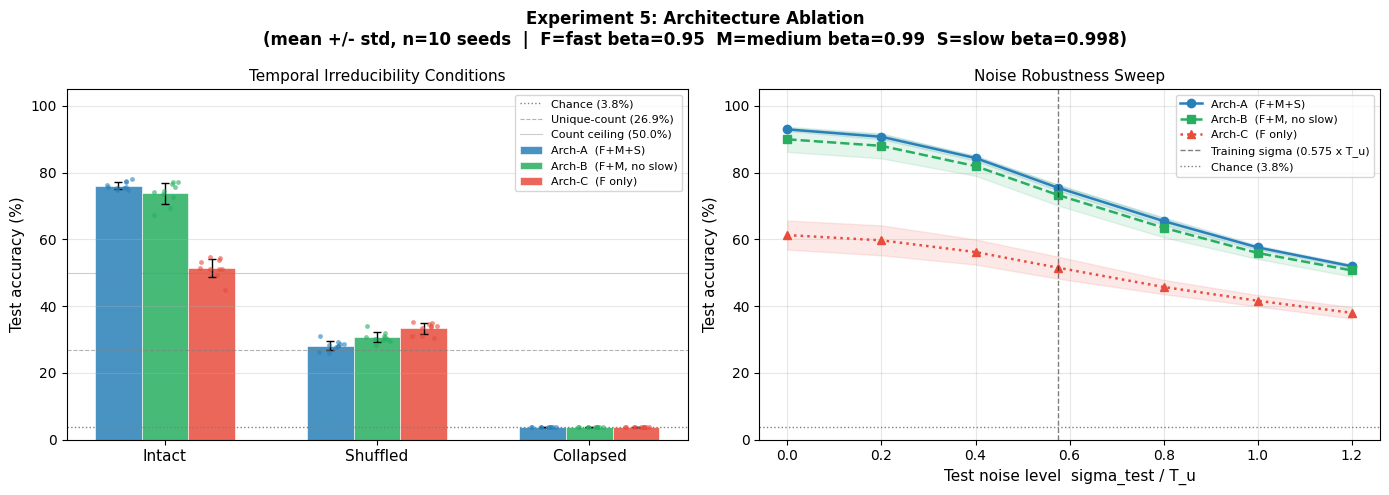

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle(
    f'Experiment 5: Architecture Ablation\n'
    f'(mean +/- std, n={N_SEEDS} seeds  |  '
    f'F=fast beta=0.95  M=medium beta=0.99  S=slow beta=0.998)',
    fontsize=12, fontweight='bold'
)

# ── Left panel: Experiment 2 conditions ──────────────────────────────────
ax = axes[0]
cond_labels = {'intact': 'Intact', 'shuffled': 'Shuffled', 'collapsed': 'Collapsed'}
n_conds     = len(TRANSFORMS)
n_archs     = len(ARCH_IDS)
bar_w       = 0.22
offsets     = np.linspace(-(n_archs-1)/2 * bar_w, (n_archs-1)/2 * bar_w, n_archs)
x_centers   = np.arange(n_conds)

for ai, aid in enumerate(ARCH_IDS):
    cfg = ARCH_CONFIGS[aid]
    for ci, cond in enumerate(TRANSFORMS):
        vals = [v * 100 for v in exp2_results[aid][cond]]
        m, s = np.mean(vals), np.std(vals)
        xpos = x_centers[ci] + offsets[ai]
        ax.bar(xpos, m, width=bar_w, color=cfg['color'], alpha=0.85,
               label=cfg['label'] if ci == 0 else None,
               edgecolor='white', linewidth=0.5)
        ax.errorbar(xpos, m, yerr=s, fmt='none', color='black',
                    capsize=3, linewidth=1.0)
        # Per-seed dots
        jitter = np.random.default_rng(42).uniform(-bar_w*0.3, bar_w*0.3, len(vals))
        ax.scatter(xpos + jitter, vals, color=cfg['color'], s=12,
                   alpha=0.6, zorder=5, linewidths=0)

# Reference lines
ax.axhline(CHANCE,        color='gray',   linestyle=':',  linewidth=1.0,
           label=f'Chance ({CHANCE:.1f}%)')
ax.axhline(UNIQUE_COUNT,  color='gray',   linestyle='--', linewidth=0.8, alpha=0.6,
           label=f'Unique-count ({UNIQUE_COUNT:.1f}%)')
ax.axhline(COUNT_CEILING, color='gray',   linestyle='-',  linewidth=0.8, alpha=0.4,
           label=f'Count ceiling ({COUNT_CEILING:.1f}%)')

ax.set_xticks(x_centers)
ax.set_xticklabels([cond_labels[c] for c in TRANSFORMS], fontsize=11)
ax.set_ylabel('Test accuracy (%)', fontsize=11)
ax.set_title('Temporal Irreducibility Conditions', fontsize=11)
ax.legend(fontsize=8, loc='upper right')
ax.set_ylim(0, 105)
ax.grid(axis='y', alpha=0.3)

# ── Right panel: Experiment 3 noise sweep ────────────────────────────────
ax = axes[1]
x_sigma = np.array(SIGMA_TEST_FRACS)

for aid in ARCH_IDS:
    cfg = ARCH_CONFIGS[aid]
    m   = np.array(sweep_means[aid])
    s   = np.array(sweep_stds[aid])
    ax.plot(x_sigma, m, color=cfg['color'], linestyle=cfg['ls'],
            marker=cfg['marker'], markersize=6, linewidth=1.8,
            label=cfg['label'])
    ax.fill_between(x_sigma, m - s, m + s, color=cfg['color'], alpha=0.12)

# Reference lines
ax.axvline(SIGMA_FRAC, color='black', linestyle='--', linewidth=1.0, alpha=0.5,
           label=f'Training sigma ({SIGMA_FRAC} x T_u)')
ax.axhline(CHANCE, color='gray', linestyle=':', linewidth=1.0,
           label=f'Chance ({CHANCE:.1f}%)')

ax.set_xlabel('Test noise level  sigma_test / T_u', fontsize=11)
ax.set_ylabel('Test accuracy (%)', fontsize=11)
ax.set_title('Noise Robustness Sweep', fontsize=11)
ax.legend(fontsize=8, loc='upper right')
ax.set_ylim(0, 105)
ax.grid(alpha=0.3)

plt.tight_layout()

fig_path = os.path.join('..', 'figures', 'exp5_architecture_ablation.pdf')
fig.savefig(fig_path, bbox_inches='tight')
print(f'Figure saved to: {fig_path}')
plt.show()

## R2.9: β Sensitivity Sweep

Tests two alternative β triples for Arch-A to verify that the specific values
(0.95 / 0.99 / 0.998) are not essential and that the multi-timescale advantage
is robust to nearby choices. Each alternative is trained for 5 seeds.

| Config | Fast | Medium | Slow |
|--------|------|--------|------|
| Arch-A (paper) | β=0.95, τ≈20 ms | β=0.99, τ≈100 ms | β=0.998, τ≈500 ms |
| Alt-1 | β=0.95, τ≈20 ms | β=0.98, τ≈50 ms  | β=0.995, τ≈200 ms |
| Alt-2 | β=0.95, τ≈20 ms | β=0.99, τ≈100 ms | β=0.999, τ≈1000 ms |


In [14]:
# ── R2.9: β sensitivity — alternative Arch-A configurations ─────────────────
BETA_ALTS = {
    'Alt-1': [(42, 0.95, 0.3), (43, 0.98, 0.4), (43, 0.995, 0.5)],
    'Alt-2': [(42, 0.95, 0.3), (43, 0.99, 0.4), (43, 0.999, 0.5)],
}
N_SEEDS_BETA = 5


def _beta_ckpt_path(config_name, train_seed):
    return os.path.join(CHECKPOINT_DIR, f'beta_{config_name}_seed{train_seed}.pt')


def _beta_train_task(config_name, groups, si):
    seed       = 42 + si + 200
    train_seed = seed * 2 + 99
    path       = _beta_ckpt_path(config_name, train_seed)

    gpu_idx = _gpool.get()
    dev     = GPU_DEVICES[gpu_idx]
    try:
        if os.path.exists(path):
            with _print_lock:
                print(f'\u21ba {config_name}  seed={train_seed}  loading checkpoint from disk')
            ckpt      = torch.load(path, map_location=dev, weights_only=False)
            model_alt = TempoSNN(ckpt['groups']).to(dev)
            model_alt.load_state_dict(ckpt['state_dict'])
        else:
            with _print_lock:
                print(f'\u2192 {config_name}  seed={train_seed}  training on {dev}')
            rng_train = np.random.default_rng(seed + 2000)
            X_tr, y_tr = generate_train_split(
                LETTERS, N_TRAIN, T_U, MAX_T, rng_train,
                label=f'{config_name}/seed={train_seed}')
            X_tr = X_tr.to(dev, non_blocking=True)
            y_tr = y_tr.to(dev, non_blocking=True)
            if dev.type == 'cuda':
                torch.cuda.synchronize(dev)

            model_alt, losses, accs_tr = train_model(
                groups, X_tr, y_tr,
                N_EPOCHS, BATCH_SIZE, dev, train_seed,
                label=config_name, use_amp=USE_AMP, use_graph=USE_CUDA_GRAPH,
            )

            del X_tr, y_tr
            if dev.type == 'cuda':
                torch.cuda.synchronize(dev)
                torch.cuda.empty_cache()

            torch.save({
                'config_name': config_name,
                'groups'     : groups,
                'seed'       : train_seed,
                'state_dict' : model_alt.state_dict(),
                'losses'     : losses,
                'accs'       : accs_tr,
            }, path)
            with _print_lock:
                print(f'  \u2713 saved: {os.path.basename(path)}')

        rng_test = np.random.default_rng(seed + 210_000)
        X_te, y_te = generate_test_split(
            LETTERS, N_TEST, T_U, MAX_T, SIGMA_FRAC * T_U, rng_test)
        acc_intact = evaluate(model_alt, X_te, y_te, dev)

        rng_shuf = np.random.default_rng(seed + 220_000)
        X_shuf   = torch.stack([transform_shuffled(x, rng_shuf) for x in X_te])
        acc_shuf = evaluate(model_alt, X_shuf, y_te, dev)

        with _print_lock:
            print(f'  {config_name} seed {seed}: intact={acc_intact*100:.1f}%  '
                  f'shuffled={acc_shuf*100:.1f}%')
        return config_name, acc_intact * 100, acc_shuf * 100
    finally:
        _gpool.put(gpu_idx)


beta_results = {cn: [] for cn in BETA_ALTS}
beta_tasks   = [(cn, grp, si)
                for cn, grp in BETA_ALTS.items()
                for si in range(N_SEEDS_BETA)]

with concurrent.futures.ThreadPoolExecutor(max_workers=N_GPU_WORKERS) as executor:
    futures = [executor.submit(_beta_train_task, cn, grp, si)
               for cn, grp, si in beta_tasks]
    for fut in concurrent.futures.as_completed(futures):
        cn, acc_intact, acc_shuf = fut.result()
        beta_results[cn].append((acc_intact, acc_shuf))

print()
print('\u03b2 sensitivity summary (mean \u00b1 std, 5 seeds):')

# Arch-A paper values for comparison
arch_a_intact = [exp2_results['A']['intact'][si] * 100 for si in range(N_SEEDS)]
print(f'  Arch-A (paper):  intact={np.mean(arch_a_intact):.1f}% \u00b1 {np.std(arch_a_intact):.1f}%')

for config_name, accs in beta_results.items():
    intact_vals = [a[0] for a in accs]
    shuf_vals   = [a[1] for a in accs]
    print(f'  {config_name}:        intact={np.mean(intact_vals):.1f}% \u00b1 {np.std(intact_vals):.1f}%  '
          f'shuffled={np.mean(shuf_vals):.1f}% \u00b1 {np.std(shuf_vals):.1f}%')

→ Alt-1  seed=583  training on cuda:1
→ Alt-1  seed=585  training on cuda:2
→ Alt-1  seed=587  training on cuda:0
  Alt-1/seed=583: 500/13000

  Alt-1/seed=587: 500/13000

  Alt-1/seed=583: 1000/13000

  Alt-1/seed=587: 1000/13000

  Alt-1/seed=585: 1000/13000

...

  [Alt-2 seed=591] epoch  50  loss=1.2667  acc=70.0%


  [Alt-2 seed=591] epoch  75  loss=1.1119  acc=75.4%


  [Alt-2 seed=591] epoch 100  loss=1.0839  acc=76.4%
  [Alt-2] seed=591 DONE  train_acc=76.4%


  ✓ saved: beta_Alt-2_seed591.pt


  Alt-2 seed 246: intact=75.8%  shuffled=30.6%

β sensitivity summary (mean ± std, 5 seeds):
  Arch-A (paper):  intact=76.1% ± 1.1%
  Alt-1:        intact=75.6% ± 1.2%  shuffled=29.4% ± 2.1%
  Alt-2:        intact=75.8% ± 0.9%  shuffled=28.4% ± 1.7%


## R1.4: Spike Count and Latency Metrics

Computes mean spike counts and mean time-to-first-output-spike for each
architecture using the trained models at the protocol noise level.
These metrics quantify computational cost beyond classification accuracy.


In [15]:
# ── R1.4: Spike count and time-to-first-spike per architecture ──────────────
import torch.nn.functional as F_

def measure_spike_metrics(model, X, device, t_u):
    """
    Instrumented forward pass that records per-layer spike counts and
    the time step at which each output neuron first fires.

    Returns:
        hidden_spikes : mean total hidden spikes per inference
        output_spikes : mean total output spikes per inference  
        ttfs_ms       : mean time-to-first-output-spike (ms); None if no output spikes
    """
    model.eval()
    X = X.to(device)                    # [N, T, 2]
    N, T, _ = X.shape

    total_hidden = 0.0
    total_output = 0.0
    ttfs_list    = []

    with torch.no_grad():
        for n in range(N):
            x = X[n].unsqueeze(1)   # [T, 1, 2]

            # Use model's actual trained LIFs (correct learned beta values)
            mems    = [lif.init_leaky() for lif in model.lifs]
            mem_out = model.lif2.init_leaky()

            h_spikes_t = []
            o_spikes_t = []

            for t in range(T):
                inp = x[t]   # [1, 2]
                h   = F_.linear(inp, model.fc1.weight, model.fc1.bias)  # [1, n_hid]

                parts, new_mems, offset = [], [], 0
                for lif, n_neu, mem in zip(model.lifs, model._sizes, mems):
                    sp, m = lif(h[:, offset:offset + n_neu], mem)
                    parts.append(sp)
                    new_mems.append(m)
                    offset += n_neu
                mems   = new_mems
                sp_all = torch.cat(parts, dim=1)   # [1, n_hid]
                h_spikes_t.append(sp_all.sum().item())

                out_inp        = F_.linear(sp_all, model.fc2.weight, model.fc2.bias)
                sp_out, mem_out = model.lif2(out_inp, mem_out)
                o_spikes_t.append(sp_out.sum().item())

            h_arr = np.array(h_spikes_t)
            o_arr = np.array(o_spikes_t)
            total_hidden += h_arr.sum()
            total_output += o_arr.sum()

            fired = np.where(o_arr > 0)[0]
            ttfs_list.append(fired[0] * 1.0 if len(fired) > 0 else None)

    valid_ttfs = [v for v in ttfs_list if v is not None]
    return (total_hidden / N,
            total_output / N,
            np.mean(valid_ttfs) if valid_ttfs else float('nan'))

# Run metrics on Arch-A, B, C using first trained seed (seed 42)
print('Spike count and latency metrics (seed 42, sigma=SIGMA_FRAC*T_u, N=100 test samples):')
print(f'{"Arch":<8}  {"Hidden spikes/inf":>18}  {"Output spikes/inf":>18}  {"TTFS (ms)":>10}')
print('-' * 62)

# Load representative test data
rng_metric = np.random.default_rng(42 * 100_000 + 50_000)
X_metric, y_metric = generate_test_split(
    LETTERS, N_TEST, T_U, MAX_T, SIGMA_FRAC * T_U, rng_metric)
dev_m = GPU_DEVICES[0] if GPU_DEVICES else device

for arch_id in ARCH_IDS:
    # Use the first-seed trained model (already in memory in results dict)
    ckpt = os.path.join(CHECKPOINT_DIR, f'arch{arch_id}_seed42.pt')
    model_m = TempoSNN(ARCH_CONFIGS[arch_id]['groups']).to(dev_m)
    if os.path.exists(ckpt):
        ckpt_data = torch.load(ckpt, map_location=dev_m, weights_only=False)
        model_m.load_state_dict(ckpt_data['state_dict'])
    h_sp, o_sp, ttfs_ts = measure_spike_metrics(model_m, X_metric, dev_m, T_U)
    ttfs_ms = ttfs_ts * 1.0   # already in ms bins (1 bin = 1 ms)
    print(f'Arch-{arch_id:<4}  {h_sp:>18.1f}  {o_sp:>18.1f}  {ttfs_ms:>10.1f}')

print()
print('Note: TTFS = time-to-first output spike (ms). Hidden = total hidden-layer')
print('      spikes per inference; Output = total output-layer spikes per inference.')


Spike count and latency metrics (seed 42, sigma=SIGMA_FRAC*T_u, N=100 test samples):
Arch       Hidden spikes/inf   Output spikes/inf   TTFS (ms)
--------------------------------------------------------------


Arch-A                 1000.5              2226.8        12.7


Arch-B                 1359.0              2961.8        11.8


Arch-C                 1472.1              2723.6        12.7

Note: TTFS = time-to-first output spike (ms). Hidden = total hidden-layer
      spikes per inference; Output = total output-layer spikes per inference.


## Summary and Success Criteria

In [16]:
print('=' * 70)
print('Experiment 5: Architecture Ablation — Summary')
print('=' * 70)
print()

# Compute key numbers
results_summary = {}
for aid in ARCH_IDS:
    i_vals = [v*100 for v in exp2_results[aid]['intact']]
    s_vals = [v*100 for v in exp2_results[aid]['shuffled']]
    c_vals = [v*100 for v in exp2_results[aid]['collapsed']]
    # Noise robustness at training sigma (0.84 x T_u)
    idx_084 = SIGMA_TEST_FRACS.index(0.80)
    r_vals  = [v*100 for v in sweep_results[aid][idx_084]]
    results_summary[aid] = {
        'intact'    : (np.mean(i_vals), np.std(i_vals)),
        'shuffled'  : (np.mean(s_vals), np.std(s_vals)),
        'collapsed' : (np.mean(c_vals), np.std(c_vals)),
        'robust_084': (np.mean(r_vals), np.std(r_vals)),
    }

print(f'{"Architecture":<32}  {"Intact":<14}  {"Shuffled":<14}  {"At sigma=0.84"}')
print('-' * 80)
for aid in ARCH_IDS:
    r = results_summary[aid]
    print(f'  {ARCH_CONFIGS[aid]["desc"]:<30}  '
          f'{r["intact"][0]:5.1f}+/-{r["intact"][1]:4.1f}  '
          f'{r["shuffled"][0]:5.1f}+/-{r["shuffled"][1]:4.1f}  '
          f'{r["robust_084"][0]:5.1f}+/-{r["robust_084"][1]:4.1f}')
print()

# Success criteria
print('Success Criteria:')

# 1. All architectures show temporal irreducibility
all_irreducible = all(
    np.mean([v*100 for v in exp2_results[aid]['intact']]) >
    np.mean([v*100 for v in exp2_results[aid]['shuffled']]) >
    np.mean([v*100 for v in exp2_results[aid]['collapsed']])
    for aid in ARCH_IDS
)
print(f'  Temporal irreducibility for all architectures : {"PASS" if all_irreducible else "FAIL"}')

# 2. Arch-C intact > count-only ceiling (task is solvable)
c_intact = np.mean([v*100 for v in exp2_results['C']['intact']])
solvable = c_intact > COUNT_CEILING
print(f'  Arch-C intact ({c_intact:.1f}%) > count ceiling ({COUNT_CEILING:.1f}%) : '
      f'{"PASS" if solvable else "FAIL"}')

# 3. Arch-A intact >= 70% (consistent with Experiments 2 and 3)
a_intact = np.mean([v*100 for v in exp2_results['A']['intact']])
baseline_ok = a_intact >= 70.0
print(f'  Arch-A intact ({a_intact:.1f}%) >= 70% (Exp 2/3 consistency) : '
      f'{"PASS" if baseline_ok else "FAIL"}')

# 4. Arch-A noise robustness at sigma=0.84 > Arch-C
a_084 = np.mean([v*100 for v in sweep_results['A'][idx_084]])
c_084 = np.mean([v*100 for v in sweep_results['C'][idx_084]])
robust_ok = a_084 > c_084
print(f'  Arch-A at sigma=0.84 ({a_084:.1f}%) > Arch-C ({c_084:.1f}%) : '
      f'{"PASS" if robust_ok else "FAIL"}')

# 5. omega-invariance: Arch-A > Arch-B degradation pattern?
a_084b = np.mean([v*100 for v in sweep_results['A'][idx_084]])
b_084  = np.mean([v*100 for v in sweep_results['B'][idx_084]])
omega_inv = a_084b > b_084
print(f'  Arch-A at sigma=0.84 ({a_084b:.1f}%) > Arch-B ({b_084:.1f}%)  '
      f'(omega-inv. supported) : {"PASS" if omega_inv else "NOT SUPPORTED"}')

print()
print('Figure output : ../figures/exp5_architecture_ablation.pdf')

Experiment 5: Architecture Ablation — Summary

Architecture                      Intact          Shuffled        At sigma=0.84
--------------------------------------------------------------------------------
  fast(42) + medium(43) + slow(43)  — benchmark model   76.1+/- 1.1   28.2+/- 1.4   65.5+/- 1.1
  fast(64) + medium(64)  — ablates ω-invariance claim   73.8+/- 3.1   30.6+/- 1.5   63.5+/- 2.9
  fast(128)  — single-timescale cross-architecture baseline   51.5+/- 2.7   33.3+/- 1.7   45.7+/- 2.1

Success Criteria:
  Temporal irreducibility for all architectures : PASS
  Arch-C intact (51.5%) > count ceiling (50.0%) : PASS
  Arch-A intact (76.1%) >= 70% (Exp 2/3 consistency) : PASS
  Arch-A at sigma=0.84 (65.5%) > Arch-C (45.7%) : PASS
  Arch-A at sigma=0.84 (65.5%) > Arch-B (63.5%)  (omega-inv. supported) : PASS

Figure output : ../figures/exp5_architecture_ablation.pdf
